## Simple example
Model: $y = 4 + 3x + \epsilon$

In [10]:
%load_ext autoreload
%autoreload 2
import numpy as np
from simple_example import generate_dataset
from shared import (
    train_weights,
    add_bias_term_to_inputs,
    create_batch_gradient_descent_compute_new_weights_function,
    create_mini_batch_gradient_descent_compute_new_weights_function,
    create_stochastic_gradient_descent_compute_new_weights_function,
)

random_generator = np.random.default_rng(42)
inputs_without_bias, outputs = generate_dataset(random_generator, dataset_size=250)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


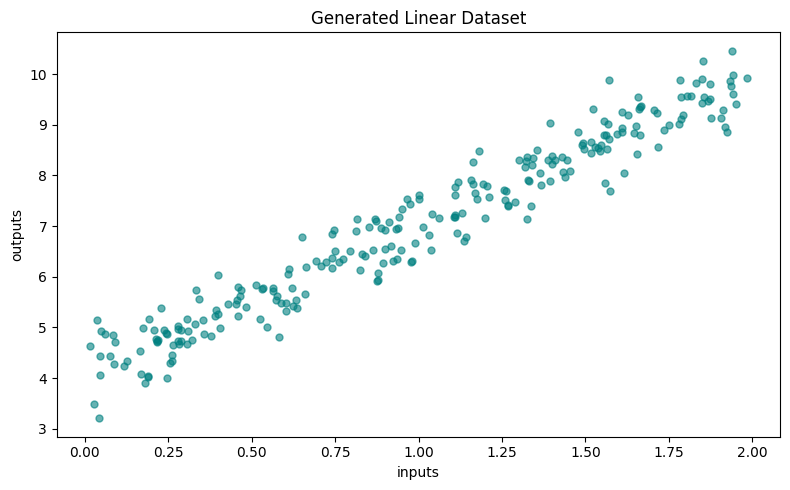

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.scatter(inputs_without_bias, outputs, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("inputs")
plt.ylabel("outputs")
plt.tight_layout()
plt.show()

In [3]:
inputs = add_bias_term_to_inputs(inputs_without_bias)
epochs = 50
results_simple = []

batch_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_batch_gradient_descent_compute_new_weights_function(
        learning_rate=0.08
    )
)
results_simple.append({
    "Method": "batch",
    "Final MSE": batch_result.loss_history[-1],
    "Training Time (s)": batch_result.training_time,
    "Final Weights": batch_result.weights.ravel()
})

mini_batch_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_mini_batch_gradient_descent_compute_new_weights_function(
        learning_rate=0.03,
        random_generator=random_generator,
        batch_size=16
    )
)
results_simple.append({
    "Method": "mini-batch",
    "Final MSE": mini_batch_result.loss_history[-1],
    "Training Time (s)": mini_batch_result.training_time,
    "Final Weights": mini_batch_result.weights.ravel()
})

stochastic_result = train_weights(
    inputs,
    initial_weights=np.zeros((inputs.shape[1], 1)),
    outputs=outputs,
    epochs=epochs,
    compute_new_weights_function=create_stochastic_gradient_descent_compute_new_weights_function(
        learning_rate=0.01,
        random_generator=random_generator,
    )
)
results_simple.append({
    "Method": "stochastic",
    "Final MSE": stochastic_result.loss_history[-1],
    "Training Time (s)": stochastic_result.training_time,
    "Final Weights": stochastic_result.weights.ravel()
})

import pandas as pd
simple_results_df = pd.DataFrame(results_simple)
simple_results_df

,Method,Final MSE,Training Time (s),Final Weights
0,batch,0.222519,0.002242,"[3.580482332201552, 3.3653000451694495]"
1,mini-batch,0.161722,0.014389,"[4.050246849999754, 2.979046456081603]"
2,stochastic,0.161435,0.056858,"[4.075043907780489, 2.953831398495118]"


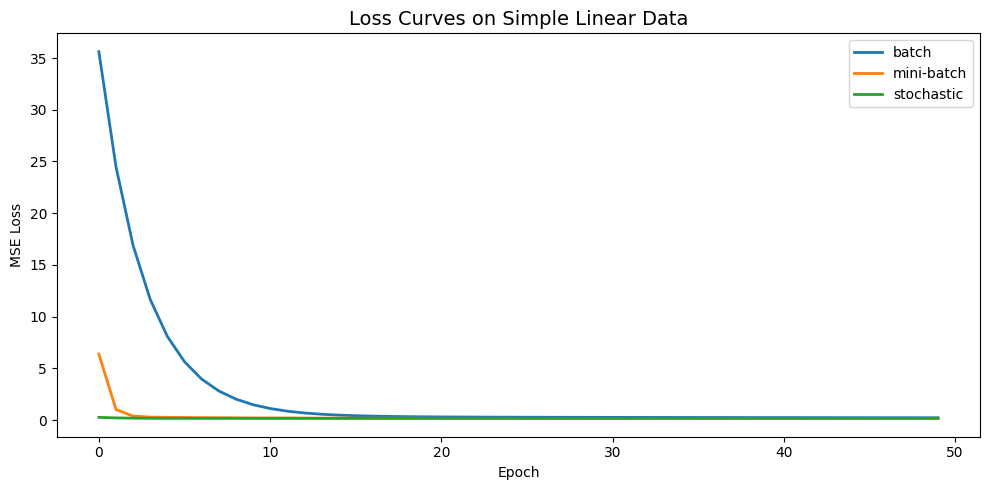

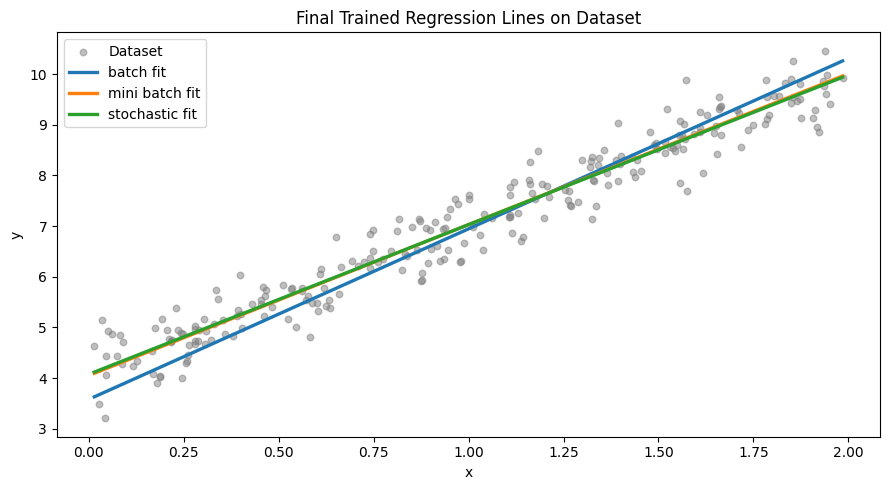

,Method,Final MSE,Training Time (s),Final Weights
2,stochastic,0.161435,0.056858,"[4.075043907780489, 2.953831398495118]"
1,mini-batch,0.161722,0.014389,"[4.050246849999754, 2.979046456081603]"
0,batch,0.222519,0.002242,"[3.580482332201552, 3.3653000451694495]"


In [5]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
plt.plot(batch_result.loss_history, label="batch", linewidth=2)
plt.plot(mini_batch_result.loss_history, label="mini-batch", linewidth=2)
plt.plot(stochastic_result.loss_history, label="stochastic", linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(inputs_without_bias.min(), inputs_without_bias.max(), inputs_without_bias.size).reshape(-1, 1)
inputs_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(inputs_without_bias, outputs, alpha=0.5, s=22, color="gray", label="Dataset")
plt.plot(x_line, inputs_line @ batch_result.weights, linewidth=2.4, label="batch fit")
plt.plot(x_line, inputs_line @ mini_batch_result.weights, linewidth=2.4, label="mini batch fit")
plt.plot(x_line, inputs_line @ stochastic_result.weights, linewidth=2.4, label="stochastic fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))